# Metadata Scaling & Query Planning — Analysis

Notebook này kiểm tra dữ liệu đo, tổng hợp thống kê, tính speedup/payback và xuất bảng/biểu đồ cho README và slide.

- **p95**: phân vị 95%, đại diện cho độ trễ ở nhóm lần chạy chậm.
- **CV**: độ lệch chuẩn chia trung bình; CV càng lớn thì phép đo càng kém ổn định.
- **PlanningSpeedup**: p95 planning của baseline chia p95 planning của biến thể; lớn hơn 1 nghĩa là nhanh hơn baseline.
- **PaybackQueries**: số truy vấn cần chạy để phần thời gian planning tiết kiệm được bù chi phí tối ưu ban đầu.

In [1]:
from pathlib import Path
import glob
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Markdown, display

# Đổi thành False ngay khi có results/results_S*.csv thật.
USE_FAKE = True
REPORT_MODE = "cold"

ROOT = Path.cwd().resolve()
if ROOT.name == "analysis":
    ROOT = ROOT.parent
CONFIG_PATH = ROOT / "config.yaml"
RESULTS_DIR = ROOT / "results"
OUTPUT_DIR = ROOT / "analysis"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

with CONFIG_PATH.open(encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

STATE_ORDER = [s for s in cfg["states"] if s != "MOCK"]
VARIANT_ORDER = cfg["variants"]
QUERY_ORDER = list(cfg["queries"])

if USE_FAKE:
    display(Markdown("## ⚠️ DỮ LIỆU GIẢ — chỉ kiểm tra pipeline, không dùng số bên dưới làm kết luận"))
else:
    display(Markdown("## DỮ LIỆU THẬT — kết quả được đọc từ `results_S*.csv`"))

mkdir -p failed for path C:\Users\ADMIN\AppData\Local\matplotlib: [WinError 5] Access is denied: 'C:\\Users\\ADMIN\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\ADMIN\AppData\Local\Temp\matplotlib-jpcluarl because there was an issue with the default path (C:\Users\ADMIN\AppData\Local\matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## ⚠️ DỮ LIỆU GIẢ — chỉ kiểm tra pipeline, không dùng số bên dưới làm kết luận

## 1. Đọc dữ liệu và kiểm tra schema

Khi `USE_FAKE=False`, notebook chỉ đọc `results_S*.csv` và không bao giờ trộn `results_fake.csv` vào kết quả thật. File chi phí được đọc độc lập từ `costs_S*.csv`.

In [2]:
RESULT_COLUMNS = [
    "state", "variant", "query", "mode", "run", "t_load",
    "t_prune", "t_plan", "t_scan", "n_files_total",
    "files_selected", "rows", "expected_rows", "hardware"
]
COST_COLUMNS = [
    "state", "variant", "op", "wall_time_s", "bytes_rewritten",
    "n_files_before", "n_files_after", "n_log_files_before",
    "n_log_files_after", "hardware"
]

def read_many(paths, required_columns, label):
    if not paths:
        raise FileNotFoundError(f"Không tìm thấy file {label}.")
    frames = []
    for path in paths:
        frame = pd.read_csv(path)
        missing = sorted(set(required_columns) - set(frame.columns))
        if missing:
            raise ValueError(f"{path.name} thiếu cột: {missing}")
        frame["source_file"] = path.name
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)

result_paths = ([RESULTS_DIR / "results_fake.csv"] if USE_FAKE
                else sorted(RESULTS_DIR.glob("results_S*.csv")))
results = read_many(result_paths, RESULT_COLUMNS, "results")
cost_paths = sorted(RESULTS_DIR.glob("costs_S*.csv"))
if cost_paths:
    costs = read_many(cost_paths, COST_COLUMNS, "costs")
else:
    costs = pd.DataFrame(columns=COST_COLUMNS + ["source_file"])
    warnings.warn("Chưa có costs_S*.csv: các cột chi phí và PaybackQueries sẽ để trống.")

numeric_columns = [
    "run", "t_load", "t_prune", "t_plan", "t_scan",
    "n_files_total", "files_selected", "rows", "expected_rows"
]
results[numeric_columns] = results[numeric_columns].apply(pd.to_numeric, errors="raise")
results["t_total"] = results["t_plan"] + results["t_scan"]
results["planning_fraction"] = np.divide(
    results["t_plan"], results["t_total"],
    out=np.full(len(results), np.nan), where=results["t_total"].ne(0)
)

print("Result files:", [p.name for p in result_paths])
print("Cost files:", [p.name for p in cost_paths] or "chưa có")
print(f"Số dòng đo: {len(results):,}")

Result files: ['results_fake.csv']
Cost files: chưa có
Số dòng đo: 720


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21212\3428053304.py:33: UserWarning: Chưa có costs_S*.csv: các cột chi phí và PaybackQueries sẽ để trống.
  warnings.warn("Chưa có costs_S*.csv: các cột chi phí và PaybackQueries sẽ để trống.")


## 2. Kiểm tra tính hợp lệ trước phân tích

Mọi dòng sai `rows != expected_rows` được in đầy đủ rồi notebook dừng. Bảng phần cứng giúp xác định liệu có thể so sánh thời gian tuyệt đối giữa các state hay chỉ nên so sánh speedup.

In [3]:
bad_rows = results.loc[results["rows"].ne(results["expected_rows"]), RESULT_COLUMNS + ["source_file"]]
print(f"Số dòng rows != expected_rows: {len(bad_rows)}")
if not bad_rows.empty:
    display(bad_rows)
    raise AssertionError("DỪNG PHÂN TÍCH: có rows != expected_rows; báo Phong và người chạy state ngay.")

hardware_by_state = (results.groupby("state", observed=True)["hardware"]
                     .agg(lambda x: sorted(x.dropna().astype(str).unique()))
                     .reset_index())
display(hardware_by_state)
all_hardware = sorted(results["hardware"].dropna().astype(str).unique())
CROSS_HARDWARE = len(all_hardware) > 1
if CROSS_HARDWARE:
    display(Markdown("**Cảnh báo:** các state chạy trên phần cứng khác nhau. Chỉ so sánh speedup giữa state; không so sánh thời gian tuyệt đối giữa state."))
else:
    print("Các state dùng cùng một giá trị hardware.")

run_counts = (results.groupby(["state", "variant", "query", "mode"], observed=True)
              .agg(n_runs=("run", "nunique"), rows_measured=("run", "size"))
              .reset_index())
unexpected_runs = run_counts.loc[run_counts["n_runs"].ne(cfg["n_runs"])]
if not unexpected_runs.empty:
    warnings.warn(f"Có {len(unexpected_runs)} tổ hợp không đủ {cfg['n_runs']} run.")
    display(unexpected_runs)
display(run_counts)

Số dòng rows != expected_rows: 0


,state,hardware
0,S1,[FAKE]
1,S2,[FAKE]
2,S3,[FAKE]
3,S4,[FAKE]


Các state dùng cùng một giá trị hardware.


,state,variant,query,mode,n_runs,rows_measured
0,S1,baseline,q_alt,cold,10,10
1,S1,baseline,q_alt,warm,10,10
2,S1,baseline,q_empty,cold,10,10
3,S1,baseline,q_empty,warm,10,10
4,S1,baseline,q_main,cold,10,10
...,...,...,...,...,...,...
67,S4,opt_b_sorted,q_alt,warm,10,10
68,S4,opt_b_sorted,q_empty,cold,10,10
69,S4,opt_b_sorted,q_empty,warm,10,10
70,S4,opt_b_sorted,q_main,cold,10,10


## 3. Thống kê theo state × variant × query × mode

In [4]:
GROUP_KEYS = ["state", "variant", "query", "mode"]

def p95(series):
    return series.quantile(0.95)

def metric_summary(frame, column):
    out = (frame.groupby(GROUP_KEYS, observed=True)[column]
           .agg(p50="median", p95=p95, mean="mean", std="std")
           .reset_index())
    out["cv"] = np.divide(out["std"], out["mean"],
                          out=np.full(len(out), np.nan), where=out["mean"].ne(0))
    return out.rename(columns={c: f"{column}_{c}" for c in ["p50", "p95", "mean", "std", "cv"]})

statistics = metric_summary(results, "t_plan")
for metric in ["t_scan", "t_total"]:
    statistics = statistics.merge(metric_summary(results, metric), on=GROUP_KEYS, validate="one_to_one")
files_mean = (results.groupby(GROUP_KEYS, observed=True)["files_selected"]
              .mean().rename("files_selected_mean").reset_index())
statistics = statistics.merge(files_mean, on=GROUP_KEYS, validate="one_to_one")
statistics.to_csv(TABLES_DIR / "summary_statistics.csv", index=False)
display(statistics)

,state,variant,query,mode,t_plan_p50,t_plan_p95,t_plan_mean,t_plan_std,t_plan_cv,t_scan_p50,t_scan_p95,t_scan_mean,t_scan_std,t_scan_cv,t_total_p50,t_total_p95,t_total_mean,t_total_std,t_total_cv,files_selected_mean
0,S1,baseline,q_alt,cold,0.002358,0.002632,0.002343,0.000275,0.117342,0.020662,0.023474,0.020972,0.002052,0.097862,0.023090,0.026045,0.023316,0.002118,0.090837,100.0
1,S1,baseline,q_alt,warm,0.002380,0.002634,0.002281,0.000315,0.138039,0.020721,0.023077,0.020226,0.002149,0.106231,0.022777,0.025372,0.022507,0.002224,0.098813,100.0
2,S1,baseline,q_empty,cold,0.001993,0.002656,0.002138,0.000369,0.172581,0.000000,0.000000,0.000000,0.000000,NaN,0.001993,0.002656,0.002138,0.000369,0.172581,0.0
3,S1,baseline,q_empty,warm,0.002044,0.002391,0.002115,0.000191,0.090449,0.000000,0.000000,0.000000,0.000000,NaN,0.002044,0.002391,0.002115,0.000191,0.090449,0.0
4,S1,baseline,q_main,cold,0.002314,0.002542,0.002270,0.000236,0.104106,0.019925,0.023804,0.020642,0.001868,0.090475,0.022313,0.025956,0.022913,0.001806,0.078807,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,S4,opt_b_sorted,q_alt,warm,0.066397,0.074438,0.066879,0.005693,0.085119,3.679484,4.400123,3.729259,0.457034,0.122554,3.745945,4.469240,3.796138,0.455750,0.120056,20000.0
68,S4,opt_b_sorted,q_empty,cold,0.060221,0.064926,0.059681,0.003814,0.063910,0.000000,0.000000,0.000000,0.000000,NaN,0.060221,0.064926,0.059681,0.003814,0.063910,0.0
69,S4,opt_b_sorted,q_empty,warm,0.061466,0.070078,0.061712,0.005826,0.094406,0.000000,0.000000,0.000000,0.000000,NaN,0.061466,0.070078,0.061712,0.005826,0.094406,0.0
70,S4,opt_b_sorted,q_main,cold,0.062132,0.068070,0.062145,0.004939,0.079478,0.021575,0.023746,0.020677,0.002899,0.140201,0.083128,0.089032,0.082822,0.004630,0.055898,100.0


## 4. PlanningSpeedup và speedup tổng thời gian

In [5]:
speedups = statistics[[*GROUP_KEYS, "t_plan_p95", "t_total_p95"]].copy()
baseline = (speedups.loc[speedups["variant"].eq("baseline"),
                         ["state", "query", "mode", "t_plan_p95", "t_total_p95"]]
            .rename(columns={"t_plan_p95": "baseline_t_plan_p95",
                             "t_total_p95": "baseline_t_total_p95"}))
speedups = speedups.merge(baseline, on=["state", "query", "mode"], validate="many_to_one")
speedups["PlanningSpeedup"] = speedups["baseline_t_plan_p95"] / speedups["t_plan_p95"]
speedups["TotalTimeSpeedup"] = speedups["baseline_t_total_p95"] / speedups["t_total_p95"]
speedups.to_csv(TABLES_DIR / "speedups.csv", index=False)
display(speedups)

,state,variant,query,mode,t_plan_p95,t_total_p95,baseline_t_plan_p95,baseline_t_total_p95,PlanningSpeedup,TotalTimeSpeedup
0,S1,baseline,q_alt,cold,0.002632,0.026045,0.002632,0.026045,1.000000,1.000000
1,S1,baseline,q_alt,warm,0.002634,0.025372,0.002634,0.025372,1.000000,1.000000
2,S1,baseline,q_empty,cold,0.002656,0.002656,0.002656,0.002656,1.000000,1.000000
3,S1,baseline,q_empty,warm,0.002391,0.002391,0.002391,0.002391,1.000000,1.000000
4,S1,baseline,q_main,cold,0.002542,0.025956,0.002542,0.025956,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
67,S4,opt_b_sorted,q_alt,warm,0.074438,4.469240,0.499605,5.198802,6.711708,1.163241
68,S4,opt_b_sorted,q_empty,cold,0.064926,0.064926,0.500700,0.500700,7.711846,7.711846
69,S4,opt_b_sorted,q_empty,warm,0.070078,0.070078,0.534227,0.534227,7.623307,7.623307
70,S4,opt_b_sorted,q_main,cold,0.068070,0.089032,0.510365,5.202335,7.497642,58.432152


## 5. Biểu đồ 1 — p95 planning theo số file (cold, q_empty, log–log)

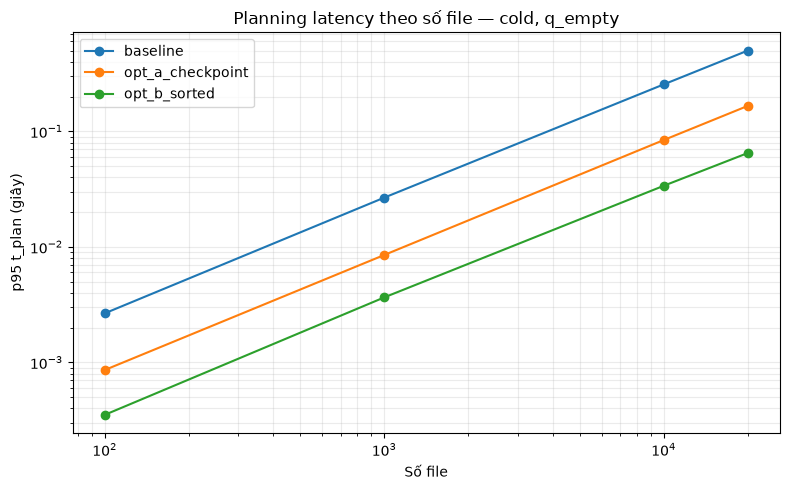

In [6]:
plot1 = statistics.loc[(statistics["query"] == "q_empty") & (statistics["mode"] == "cold")].copy()
file_counts = (results.groupby(["state", "variant"], observed=True)["n_files_total"]
               .first().rename("n_files_total").reset_index())
plot1 = plot1.merge(file_counts, on=["state", "variant"], validate="one_to_one")
fig, ax = plt.subplots(figsize=(8, 5))
for variant in VARIANT_ORDER:
    part = plot1.loc[plot1["variant"].eq(variant)].sort_values("n_files_total")
    if not part.empty:
        ax.plot(part["n_files_total"], part["t_plan_p95"], marker="o", label=variant)
ax.set(xscale="log", yscale="log", xlabel="Số file", ylabel="p95 t_plan (giây)",
       title="Planning latency theo số file — cold, q_empty")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "p95_t_plan_q_empty_cold_loglog.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Biểu đồ 2 — tỷ lệ planning trong tổng thời gian (q_main)

Tỷ lệ được tính trên từng run rồi lấy trung bình; biểu đồ dùng `REPORT_MODE` để cold và warm không bị trộn lẫn.

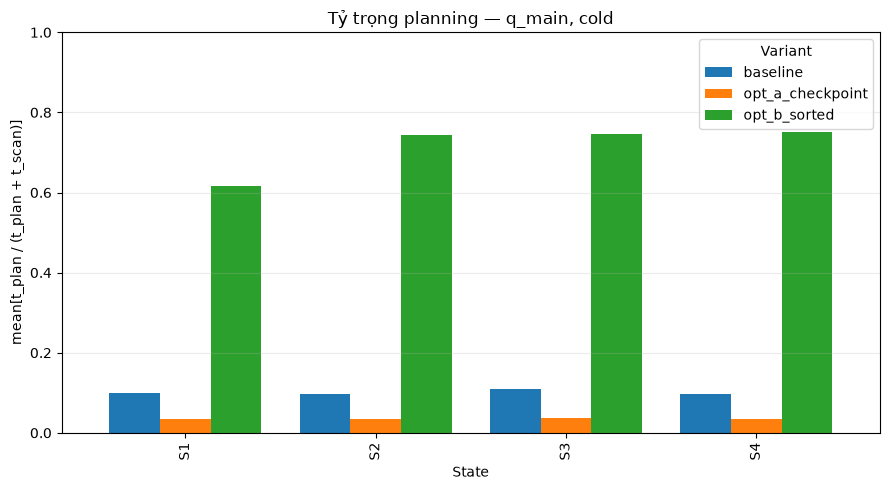

In [7]:
plot2 = (results.loc[(results["query"] == "q_main") & (results["mode"] == REPORT_MODE)]
         .groupby(["state", "variant"], observed=True)["planning_fraction"].mean()
         .unstack("variant").reindex(index=STATE_ORDER, columns=VARIANT_ORDER))
ax = plot2.plot(kind="bar", figsize=(9, 5), width=0.8)
ax.set(xlabel="State", ylabel="mean[t_plan / (t_plan + t_scan)]",
       title=f"Tỷ trọng planning — q_main, {REPORT_MODE}")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Variant")
ax.figure.tight_layout()
ax.figure.savefig(FIGURES_DIR / f"planning_fraction_q_main_{REPORT_MODE}.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. Bảng chính S4 held-out và PaybackQueries

Chi phí của nhiều operation thuộc cùng state/variant được cộng lại. Nếu biến thể không tiết kiệm planning time (`delta <= 0`) thì PaybackQueries là vô hạn; nếu chưa có file cost thì để trống.

In [8]:
HELDOUT = cfg["heldout"][0]
s4 = speedups.loc[(speedups["state"] == HELDOUT) & (speedups["mode"] == REPORT_MODE)].copy()
means = statistics[[*GROUP_KEYS, "t_plan_mean"]]
base_means = (means.loc[means["variant"].eq("baseline"), ["state", "query", "mode", "t_plan_mean"]]
              .rename(columns={"t_plan_mean": "baseline_t_plan_mean"}))
s4 = s4.merge(means, on=GROUP_KEYS, validate="one_to_one")
s4 = s4.merge(base_means, on=["state", "query", "mode"], validate="many_to_one")
if not costs.empty:
    cost_summary = (costs.groupby(["state", "variant"], observed=True)
                    .agg(wall_time_s=("wall_time_s", "sum"),
                         bytes_rewritten=("bytes_rewritten", "sum"))
                    .reset_index())
    s4 = s4.merge(cost_summary, on=["state", "variant"], how="left", validate="many_to_one")
else:
    s4["wall_time_s"] = np.nan
    s4["bytes_rewritten"] = np.nan

saving = s4["baseline_t_plan_mean"] - s4["t_plan_mean"]
s4["PaybackQueries"] = np.where(saving > 0, s4["wall_time_s"] / saving, np.inf)
s4.loc[s4["wall_time_s"].isna(), "PaybackQueries"] = np.nan
main_columns = ["state", "variant", "query", "mode", "PlanningSpeedup",
                "TotalTimeSpeedup", "wall_time_s", "bytes_rewritten", "PaybackQueries"]
s4_main = s4[main_columns].sort_values(["query", "variant"])
s4_main.to_csv(TABLES_DIR / "s4_heldout_main.csv", index=False)
display(s4_main)

,state,variant,query,mode,PlanningSpeedup,TotalTimeSpeedup,wall_time_s,bytes_rewritten,PaybackQueries
0,S4,baseline,q_alt,cold,1.000000,1.000000,NaN,NaN,NaN
3,S4,opt_a_checkpoint,q_alt,cold,3.124626,1.069023,NaN,NaN,NaN
6,S4,opt_b_sorted,q_alt,cold,7.299935,1.103802,NaN,NaN,NaN
1,S4,baseline,q_empty,cold,1.000000,1.000000,NaN,NaN,NaN
4,S4,opt_a_checkpoint,q_empty,cold,3.012924,3.012924,NaN,NaN,NaN
7,S4,opt_b_sorted,q_empty,cold,7.711846,7.711846,NaN,NaN,NaN
2,S4,baseline,q_main,cold,1.000000,1.000000,NaN,NaN,NaN
5,S4,opt_a_checkpoint,q_main,cold,3.002954,1.074575,NaN,NaN,NaN
8,S4,opt_b_sorted,q_main,cold,7.497642,58.432152,NaN,NaN,NaN


## 8. Xuất Markdown và tạo nhận xét có số liệu

Các câu bên dưới được sinh trực tiếp từ dữ liệu. Với dữ liệu giả, chúng chỉ là bản xem trước bố cục và được ghi vào file riêng có cảnh báo.

In [9]:
def dataframe_to_markdown(frame, digits=4):
    printable = frame.copy()
    for col in printable.select_dtypes(include=[np.number]).columns:
        printable[col] = printable[col].map(lambda x: "" if pd.isna(x) else ("∞" if np.isinf(x) else f"{x:.{digits}g}"))
    headers = [str(c) for c in printable.columns]
    rows = [[str(v).replace("|", "\|") for v in row] for row in printable.astype(str).values.tolist()]
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]
    lines.extend("| " + " | ".join(row) + " |" for row in rows)
    return "\n".join(lines)

(TABLES_DIR / "summary_statistics.md").write_text(dataframe_to_markdown(statistics), encoding="utf-8")
(TABLES_DIR / "speedups.md").write_text(dataframe_to_markdown(speedups), encoding="utf-8")
(TABLES_DIR / "s4_heldout_main.md").write_text(dataframe_to_markdown(s4_main), encoding="utf-8")

def value_at(frame, variant, query, column, state=HELDOUT, mode=REPORT_MODE):
    hit = frame.loc[(frame["state"] == state) & (frame["variant"] == variant) &
                    (frame["query"] == query) & (frame["mode"] == mode), column]
    return float(hit.iloc[0]) if len(hit) else np.nan

largest_state = next((s for s in reversed(STATE_ORDER) if s in set(results["state"])), results["state"].iloc[-1])
alt_speedup = value_at(speedups, "opt_b_sorted", "q_alt", "PlanningSpeedup", state=largest_state)
s1_checkpoint = value_at(speedups, "opt_a_checkpoint", "q_empty", "PlanningSpeedup", state="S1")
scan_plan = results.loc[(results["state"] == largest_state) & (results["variant"] == "baseline") &
                        (results["query"] == "q_main") & (results["mode"] == REPORT_MODE)]
scan_over_plan = scan_plan["t_scan"].mean() / scan_plan["t_plan"].mean() if not scan_plan.empty else np.nan
main_speedup = value_at(speedups, "opt_b_sorted", "q_main", "PlanningSpeedup", state=largest_state)
total_speedup = value_at(speedups, "opt_b_sorted", "q_main", "TotalTimeSpeedup", state=largest_state)
payback_hit = s4_main.loc[(s4_main["variant"] == "opt_b_sorted") & (s4_main["query"] == "q_main"), "PaybackQueries"]
payback = float(payback_hit.iloc[0]) if len(payback_hit) else np.nan

prefix = "**BẢN XEM TRƯỚC TỪ DỮ LIỆU GIẢ — KHÔNG TRÍCH DẪN LÀM KẾT QUẢ.**\n\n" if USE_FAKE else ""
findings = [
    f"Ở {largest_state} ({REPORT_MODE}), opt_b_sorted đạt PlanningSpeedup {main_speedup:.2f}× cho q_main; speedup tổng thời gian là {total_speedup:.2f}×.",
    f"Failure case q_alt trên cột không được sort: PlanningSpeedup của opt_b_sorted tại {largest_state} là {alt_speedup:.2f}×; giá trị gần 1× nghĩa là lợi ích planning không đáng kể.",
    f"Ở S1 với q_empty ({REPORT_MODE}), checkpoint đạt PlanningSpeedup {s1_checkpoint:.2f}×; cần đọc cùng thời gian tuyệt đối trước khi gọi đây là cải thiện thực dụng.",
    f"Với baseline q_main tại {largest_state}, mean t_scan lớn gấp {scan_over_plan:.2f}× mean t_plan; nếu tỷ lệ này lớn, tối ưu riêng planning ít tác động tới độ trễ đầu-cuối.",
    (f"Chi phí opt_b cho q_main tại {HELDOUT} cần khoảng {payback:.0f} truy vấn để hoàn vốn; workload ít hơn ngưỡng này không bù được chi phí rewrite."
     if np.isfinite(payback) else f"Chưa tính được PaybackQueries của opt_b tại {HELDOUT} vì thiếu chi phí thật hoặc biến thể không tiết kiệm planning time.")
]
findings_text = prefix + "\n".join(f"- {line}" for line in findings)
(TABLES_DIR / "key_findings.md").write_text(findings_text, encoding="utf-8")
display(Markdown(findings_text))

<>:6: SyntaxWarning: invalid escape sequence '\|'
<>:6: SyntaxWarning: invalid escape sequence '\|'
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21212\4254668304.py:6: SyntaxWarning: invalid escape sequence '\|'
  rows = [[str(v).replace("|", "\|") for v in row] for row in printable.astype(str).values.tolist()]


**BẢN XEM TRƯỚC TỪ DỮ LIỆU GIẢ — KHÔNG TRÍCH DẪN LÀM KẾT QUẢ.**

- Ở S4 (cold), opt_b_sorted đạt PlanningSpeedup 7.50× cho q_main; speedup tổng thời gian là 58.43×.
- Failure case q_alt trên cột không được sort: PlanningSpeedup của opt_b_sorted tại S4 là 7.30×; giá trị gần 1× nghĩa là lợi ích planning không đáng kể.
- Ở S1 với q_empty (cold), checkpoint đạt PlanningSpeedup 3.10×; cần đọc cùng thời gian tuyệt đối trước khi gọi đây là cải thiện thực dụng.
- Với baseline q_main tại S4, mean t_scan lớn gấp 9.44× mean t_plan; nếu tỷ lệ này lớn, tối ưu riêng planning ít tác động tới độ trễ đầu-cuối.
- Chưa tính được PaybackQueries của opt_b tại S4 vì thiếu chi phí thật hoặc biến thể không tiết kiệm planning time.

## 9. Danh sách file bàn giao

In [10]:
print("Figures:")
for p in sorted(FIGURES_DIR.glob("*.png")):
    print(" -", p.relative_to(ROOT))
print("Tables:")
for p in sorted(TABLES_DIR.glob("*")):
    print(" -", p.relative_to(ROOT))

Figures:
 - analysis\figures\p95_t_plan_q_empty_cold_loglog.png
 - analysis\figures\planning_fraction_q_main_cold.png
Tables:
 - analysis\tables\key_findings.md
 - analysis\tables\s4_heldout_main.csv
 - analysis\tables\s4_heldout_main.md
 - analysis\tables\speedups.csv
 - analysis\tables\speedups.md
 - analysis\tables\summary_statistics.csv
 - analysis\tables\summary_statistics.md
